In [1]:
import kagglehub
kagglehub.login()

In [2]:
path = kagglehub.competition_download("titanic")

path

100%|██████████| 34.1k/34.1k [00:00<00:00, 31.5MB/s]

Extracting files...


'/root/.cache/kagglehub/competitions/titanic'

In [30]:
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch

test_csv = pd.read_csv(path+'/test.csv')
train_csv = pd.read_csv(path+'/train.csv')

print(f"shape:{test_csv.shape, train_csv.shape}")

train_csv

shape:((418, 11), (891, 12))


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:

csv = pd.concat([train_csv, test_csv], axis=0, ignore_index=True)
csv.ffill(inplace=True)
csv.bfill(inplace=True)


names = csv['Name']
cabin = csv['Cabin']
cabin_letter = cabin.astype(str).str[0]

csv = csv.drop(columns='Name', axis=1)
csv = csv.drop(columns='Cabin', axis=1)



csv['Married'] = names.str.contains('Mrs.', na=False).astype(int)
csv['Master'] = names.str.contains('Master.', na=False).astype(int)
csv['Cabin_col'] = cabin_letter.astype('category').cat.codes

csv = csv.drop(columns='Ticket', axis=1)

csv = pd.get_dummies(csv, dtype=int, drop_first=True)

test_csv = csv.iloc[train_csv.shape[0]:]
train_csv = csv.iloc[:train_csv.shape[0]]

csv

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Married,Master,Cabin_col,Sex_male,Embarked_Q,Embarked_S
0,1,0.0,3,22.0,1,0,7.2500,0,0,2,1,0,1
1,2,1.0,1,38.0,1,0,71.2833,1,0,2,0,0,0
2,3,1.0,3,26.0,0,0,7.9250,0,0,2,0,0,1
3,4,1.0,1,35.0,1,0,53.1000,1,0,2,0,0,1
4,5,0.0,3,35.0,0,0,8.0500,0,0,2,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0.0,3,28.0,0,0,8.0500,0,0,2,1,0,1
1305,1306,0.0,1,39.0,0,0,108.9000,0,0,2,0,0,0
1306,1307,0.0,3,38.5,0,0,7.2500,0,0,2,1,0,1
1307,1308,0.0,3,38.5,0,0,8.0500,0,0,2,1,0,1


In [32]:
print(f"shape:{test_csv.shape, train_csv.shape}")

shape:((418, 13), (891, 13))


In [33]:
def to_dataset(csv):
    X = torch.tensor(csv.iloc[:, 2:].values, dtype=torch.float32)
    y = torch.tensor(csv.iloc[:, 1].values, dtype=torch.long)
    return TensorDataset(X, y)

dataset = to_dataset(train_csv)

train_size = int(0.8 * len(dataset))
valid_size = len(dataset) - train_size

train_dataset, valid_dataset = random_split(
    dataset, 
    [train_size, valid_size],
    generator=torch.Generator().manual_seed(42)
)

In [34]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
from torch.optim import AdamW
from torch import nn
import sklearn.svm as svm

lr, batch_size, num_epochs = 0.001, 128, 10

total_loss = {
    "valid": [],
    "train": []
}

model = nn.Sequential(
    nn.LazyLinear(128),
    nn.ReLU(),
    nn.LazyLinear(2)
)

model = model.to(device)

optim = AdamW(model.parameters(), lr=lr)
l = nn.CrossEntropyLoss()

train_iter = DataLoader(train_dataset, batch_size)
valid_iter = DataLoader(valid_dataset, batch_size)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for features, label in train_iter:
        features, label = features.to(device), label.to(device)
        optim.zero_grad()
        hat_label = model(features)
        loss = l(hat_label, label)
        loss.backward()
        optim.step()

        epoch_loss += loss.item()

    total_loss["train"].append(epoch_loss)
    print(f"epochs:{epoch+1}, epoch_loss:{epoch_loss}")
    model.eval()
    epoch_loss = 0.0
    with torch.no_grad():
        for features, label in valid_iter:
            features, label = features.to(device), label.to(device)
            hat_label = model(features)
            loss = l(hat_label, label)

            epoch_loss += loss.item()

    total_loss["valid"].append(epoch_loss)


AttributeError: 'LinearSVC' object has no attribute 'parameters'

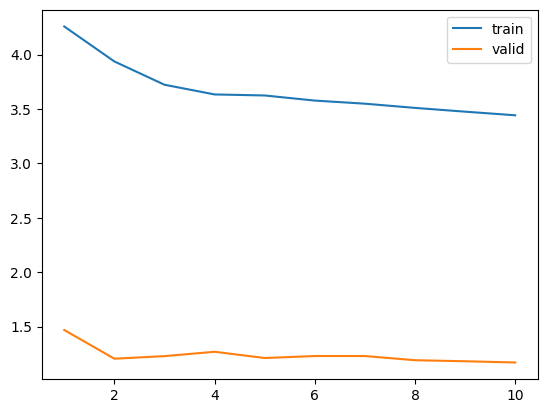

In [43]:
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs+1), total_loss["train"], label="train")
plt.plot(range(1, num_epochs+1), total_loss["valid"], label="valid")

plt.legend()

In [44]:
pd.read_csv(path+"/gender_submission.csv").iloc[:, 0]

,PassengerId
0,892
1,893
2,894
3,895
4,896
...,...
413,1305
414,1306
415,1307
416,1308


In [47]:
test = torch.tensor(test_csv.iloc[:, 2:].values, dtype=torch.float32).to(device)

model.eval()

with torch.no_grad():
    y = model(test)
    pred = torch.argmax(y, dim=1)

    pred = pred.cpu().numpy()

submission = pd.DataFrame({
    "PassengerId": pd.read_csv(path+"/gender_submission.csv").iloc[:, 0],
    "Survived": pred
})

submission_name = "titanic_submission__drop-Ticket_change-Name-Cabin-v2.csv"

submission.to_csv(submission_name, index=False)

In [48]:
from google.colab import drive
import shutil
import os

# 1. 掛載 Google Drive 到 Colab 虛擬機
# 執行後會跳出視窗請求權限，請點選「連線到 Google 雲端硬碟」並允許
drive.mount('/content/drive')

# 2. 定義來源檔案路徑與 Google Drive 的目標儲存路徑
source_path = submission_name
# 預設儲存於雲端硬碟的根目錄，您也可以自訂資料夾路徑如 '/content/drive/MyDrive/Colab Notebooks/'
target_path = '/content/drive/MyDrive/'

# 3. 檢查檔案是否存在並執行複製上傳
if os.path.exists(source_path):
    shutil.copy(source_path, target_path)
    print(f"🎉 上傳成功！")
else:
    print(f"❌ 找不到來源檔案 {source_path}，請確認先前的預測程式碼是否有成功產生 CSV 檔。")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🎉 上傳成功！
